# The ESG Premium — a quantitative teardown 🔬
### Newey-West active-return spread tests · a growth-value/quality factor decomposition · tracking error and the cost accounting · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Growth/quality tilt: Confirmed](https://img.shields.io/badge/Growth%2Fquality_tilt%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). "Doing well by doing good" is a genuinely contested claim in the academic literature (Friede/Busch/Bassen 2015 lean mildly positive; Bolton & Kacperczyk 2021's carbon premium implies ESG exclusion should be a mild *drag*; Pástor-Stambaugh-Taylor 2021 shows the sign can flip by sample window). The job here is to measure it directly on the actual investable products, then ask whether any gap survives controlling for the obvious growth/quality tilt.

> ⚠️ **Data note.** Total-return daily closes (yfinance, `auto_adjust=True`) for ESGU/SUSA/SPY/IVV/IVW/IVE/QUAL, plus ^IRX for the risk-free proxy, as-of 2026-06-30. No survivorship — every ticker is a single, currently-traded ETF over its own listed history. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints active-return `3118d66244a6` / `4820c59f2797`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from esg_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    tapes = data.load_real()
    rets = {t: st.daily_returns(tapes[t]["Close"]) for t in data.TICKERS if t != "^IRX"}
    rf = st.rf_daily(tapes["^IRX"]["Close"].reindex(rets["SPY"].index).ffill())
    gv_spread = rets["IVW"] - rets["IVE"]
else:
    rets = rf = gv_spread = None
print("real cache present:", HAVE_REAL,
      "| ESGU days:", (0 if rets is None else len(rets["ESGU"])),
      "| SUSA days:", (0 if rets is None else len(rets["SUSA"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'esgu_start': '2016-12-07', 'esgu_end': '2026-06-30', 'esgu_n': 2402, 'esgu_years': 9.5, 'esgu_cagr_fund': 15.31, 'esgu_cagr_bench': 15.45, 'esgu_vol_fund': 18.59, 'esgu_vol_bench': 18.23, 'esgu_sharpe_fund': 0.73, 'esgu_sharpe_bench': 0.747, 'esgu_te': 3.75, 'esgu_ir': -0.015, 'esgu_active_ann': -0.057, 'esgu_nw_t': -0.08, 'esgu_welch_t': -0.01, 'esgu_net_ann': -0.378, 'esgu_hit': 50.2, 'esgu_alpha_ann': -0.064, 'esgu_alpha_t': -0.09, 'esgu_beta_gv': 0.025, 'esgu_beta_gv_t': 3.63, 'esgu_beta_q': 0.109, 'esgu_beta_q_t': 3.41, 'susa_start': '2005-01-31', 'susa_end': '2026-06-30', 'susa_n': 5387, 'susa_years': 21.4, 'susa_cagr_fund': 10.5, 'susa_cagr_bench': 11.09, 'susa_vol_fund': 18.28, 'susa_vol_bench': 18.85, 'susa_sharpe_fund': 0.543, 'susa_sharpe_bench': 0.561, 'susa_te': 4.78, 'susa_ir': -0.135, 'susa_active_ann': -0.644, 'susa_nw_t': -1.07, 'susa_welch_t': -0.11, 'susa_net_ann': -0.953, 'susa_hit': 49.9, 'susa_alpha_ann': -0.187, 'susa_alpha_t': -0.27, 'susa_beta_gv': 0.001, 'susa_beta_gv_t': 0.14, 'susa_beta_q': 0.247, 'susa_beta_q_t': 8.5, 'er_esgu': 0.15, 'er_spy': 0.095, 'er_susa': 0.25, 'er_ivv': 0.03, 'er_gap_esgu': 0.055, 'er_gap_susa': 0.22, 'syn_null_mean': -0.43, 'syn_null_sd': 0.88, 'syn_null_fire': 0, 'syn_planted_bps': 4.198, 'syn_planted_t': 8.73, 'fp_esgu': '29e958663c9e', 'fp_susa': '27becb3a322e', 'fp_spy': '30a1902f6b13', 'fp_ivv': 'b5c9e7d52b50', 'fp_ivw': 'fc9dec46168d', 'fp_ive': '1988eedd21ca', 'fp_qual': '9dd22955608c', 'fp_irx': '7523780ae772', 'fp_active_esgu': '3118d66244a6', 'fp_active_susa': '4820c59f2797'}


real cache present: True | ESGU days: 2402 | SUSA days: 5387


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | ESGU−SPY NW **t = -0.08** (-0.057%/yr); SUSA−IVV NW **t = -1.07** (-0.644%/yr) — both \|t\| < 2 |
| **Tradability** | `MIRAGE` | net of costs: ESGU -0.378%/yr, SUSA -0.953%/yr, tracking error 3.75% / 4.78% |
| **Growth/quality tilt?** | `CONFIRMED` | quality beta *t* = 3.41 / 8.50; growth-value beta *t* = 3.63 (ESGU) |

> 💡 In plain words: the ESG label buys you a real, measurable factor tilt and a real fee — not a return edge in either direction.

## 1 · The claim, steelmanned

Let $r^{ESG}_t$ and $r^{B}_t$ be the daily total-return of an ESG fund and its plain-vanilla benchmark, and $a_t = r^{ESG}_t - r^{B}_t$ the daily active return.

- **H₁ (premium).** $E[a_t] > 0$ and statistically distinguishable from zero — "doing well by doing good."
- **H₂ (drag).** $E[a_t] < 0$ and statistically distinguishable — screens cost you diversification and expenses.
- **H₃ (relabelling).** Any nonzero $E[a_t]$ is explained by loadings on a growth-value spread and a quality spread, i.e. the intercept in $r^{ESG}_t = \alpha + \beta_1 r^B_t + \beta_2 (r^{IVW}_t - r^{IVE}_t) + \beta_3(r^{QUAL}_t - r^B_t) + \epsilon_t$ collapses toward zero once the tilts are priced in.

We find **neither H₁ nor H₂ supported** (both $|t| < 2$) and **H₃ partially confirmed** — the tilts ($\beta_2, \beta_3$) are statistically real, but since $E[a_t]$ was never significant to start with, the intercept doesn't collapse *from* significance — there was no alpha to explain away.

## 2 · So what? — inference design

Daily active returns between two highly-correlated large-cap total-return series are serially correlated (shared market moves, dividend-timing mismatches), so the **planned primary** is a **Newey-West (5-lag) HAC *t*** of the mean active return (equivalently, the intercept of $a_t$ regressed on a constant). A Welch *t* on the raw fund/benchmark levels is reported as a cross-check. The factor decomposition uses the same 5-lag HAC covariance on a 3-regressor OLS (market, growth-value spread, quality spread). Both legs of every Sharpe ratio are measured **excess of the same ^IRX cash proxy** — never a raw-vs-excess race.

## 3 · How we'd know — the protocol

- **Tape.** ESGU 2016-12-07 → 2026-06-30 (n=2,402, 9.5y) vs SPY; SUSA 2005-01-31 → 2026-06-30 (n=5,387, 21.4y) vs IVV. As-of 2026-06-30 (last complete month).
- **Headline.** CAGR, ann. vol, excess-of-cash Sharpe (both legs vs ^IRX), tracking error, information ratio.
- **Spread test.** NW(5) *t* of the daily active return (primary), Welch *t* (cross-check), net of 2 legs × 5 bps one-way (amortized) + 30 bps/yr benchmark-leg borrow.
- **Decomposition.** OLS of fund return on [benchmark, IVW−IVE, QUAL−benchmark], NW(5) HAC SEs; the intercept is the alpha once the tilts are priced in.
- **Control.** Synthetic correlated-return world (fund vs benchmark, ρ=0.97), planted premium knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · Tracking difference & Sharpe

CAGR, volatility and excess-of-cash Sharpe, fund vs benchmark, each pair over its own full common history.

ESGU vs SPY: 15.31 vs 15.45 %/yr CAGR; Sharpe 0.73 vs 0.747
SUSA vs IVV: 10.5 vs 11.09 %/yr CAGR; Sharpe 0.543 vs 0.561


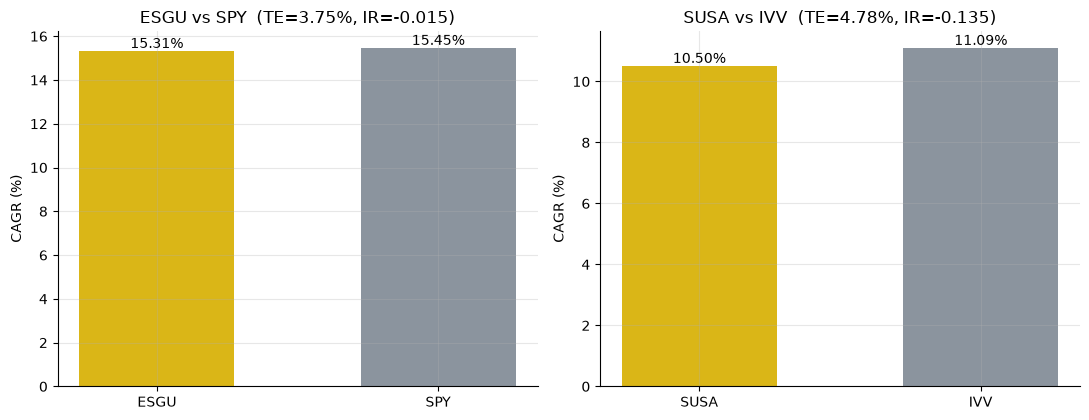

In [2]:
if HAVE_REAL:
    ts_e = st.tracking_stats(rets['ESGU'], rets['SPY'], rf)
    ts_s = st.tracking_stats(rets['SUSA'], rets['IVV'], rf)
else:
    ts_e = ts_s = None
print('ESGU vs SPY:', R['esgu_cagr_fund'], 'vs', R['esgu_cagr_bench'], '%/yr CAGR;'
      ' Sharpe', R['esgu_sharpe_fund'], 'vs', R['esgu_sharpe_bench'])
print('SUSA vs IVV:', R['susa_cagr_fund'], 'vs', R['susa_cagr_bench'], '%/yr CAGR;'
      ' Sharpe', R['susa_sharpe_fund'], 'vs', R['susa_sharpe_bench'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['ESGU','SPY'], [R['esgu_cagr_fund'], R['esgu_cagr_bench']],
       color=[AMBER, GREY], width=.55)
a1.set_title(f"ESGU vs SPY  (TE={R['esgu_te']:.2f}%, IR={R['esgu_ir']:+.3f})")
a1.set_ylabel('CAGR (%)')
for i,v in enumerate([R['esgu_cagr_fund'], R['esgu_cagr_bench']]):
    a1.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
a2.bar(['SUSA','IVV'], [R['susa_cagr_fund'], R['susa_cagr_bench']],
       color=[AMBER, GREY], width=.55)
a2.set_title(f"SUSA vs IVV  (TE={R['susa_te']:.2f}%, IR={R['susa_ir']:+.3f})")
a2.set_ylabel('CAGR (%)')
for i,v in enumerate([R['susa_cagr_fund'], R['susa_cagr_bench']]):
    a2.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()

> 💡 In plain words: CAGR and Sharpe are a hair lower for both ESG funds (ESGU Sharpe 0.730 vs SPY 0.747; SUSA 0.543 vs IVV 0.561), while carrying 3.75% / 4.78% of annualized tracking error — real basis risk versus the benchmark, for a difference that (next section) isn't even statistically real.

### 4b · The headline — active-return spread test

Newey-West (5-lag) *t* of the mean daily active return — the **primary** statistic, since the series is serially correlated.

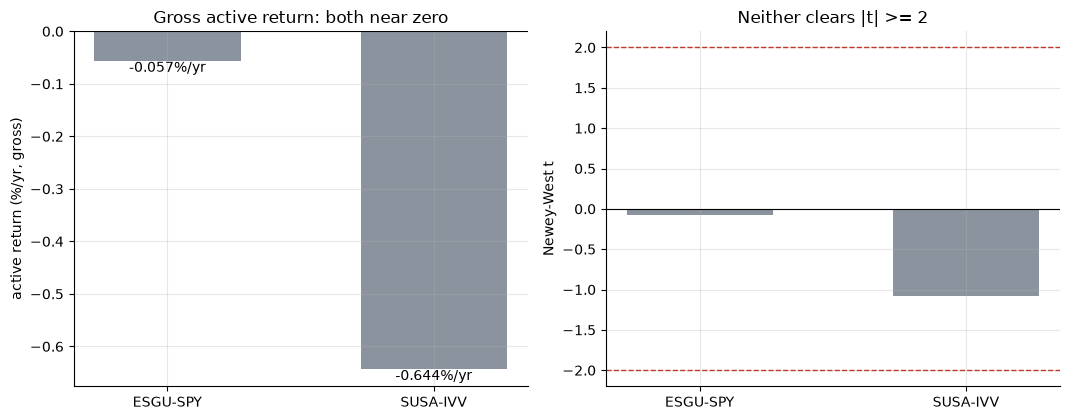

ESGU-SPY -0.057%/yr, NW t=-0.08  |  SUSA-IVV -0.644%/yr, NW t=-1.07


In [3]:
if HAVE_REAL:
    sp_e = st.spread_test(rets['ESGU'], rets['SPY'])
    sp_s = st.spread_test(rets['SUSA'], rets['IVV'])
    e_ann, e_t = sp_e['gross_ann_pct'], sp_e['nw_t']
    s_ann, s_t = sp_s['gross_ann_pct'], sp_s['nw_t']
else:
    e_ann, e_t = R['esgu_active_ann'], R['esgu_nw_t']
    s_ann, s_t = R['susa_active_ann'], R['susa_nw_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(['ESGU-SPY','SUSA-IVV'], [e_ann, s_ann], color=[GREY, GREY], width=.55)
for i,v in enumerate([e_ann, s_ann]): a1.annotate(f'{v:+.3f}%/yr',(i,v),
    ha='center', va='top' if v<0 else 'bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('active return (%/yr, gross)')
a1.set_title('Gross active return: both near zero')
a2.bar(['ESGU-SPY','SUSA-IVV'], [e_t, s_t],
       color=[RED if abs(t)>=2 else GREY for t in [e_t, s_t]], width=.55)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('Newey-West t')
a2.set_title('Neither clears |t| >= 2')
plt.tight_layout(); plt.show()
print(f'ESGU-SPY {e_ann:+.3f}%/yr, NW t={e_t:+.2f}  |  SUSA-IVV {s_ann:+.3f}%/yr, NW t={s_t:+.2f}')

> 💡 In plain words: ESGU−SPY is essentially a coin flip (hit rate 50.2%, NW *t* = -0.08); SUSA−IVV leans negative but stays short of the bar (NW *t* = -1.07). Net of the 5.5–22 bps/yr documented expense-ratio gap plus trading/borrow costs, both spreads go further negative (-0.378%/yr, -0.953%/yr) — but the *statistical* verdict was already None before a single cost was charged.

### 4c · Factor decomposition — is any gap just growth/quality?

$r^{ESG}_t = \alpha + \beta_1 r^B_t + \beta_2(r^{IVW}_t-r^{IVE}_t) + \beta_3(r^{QUAL}_t - r^B_t) + \epsilon_t$, Newey-West (5-lag) HAC SEs.

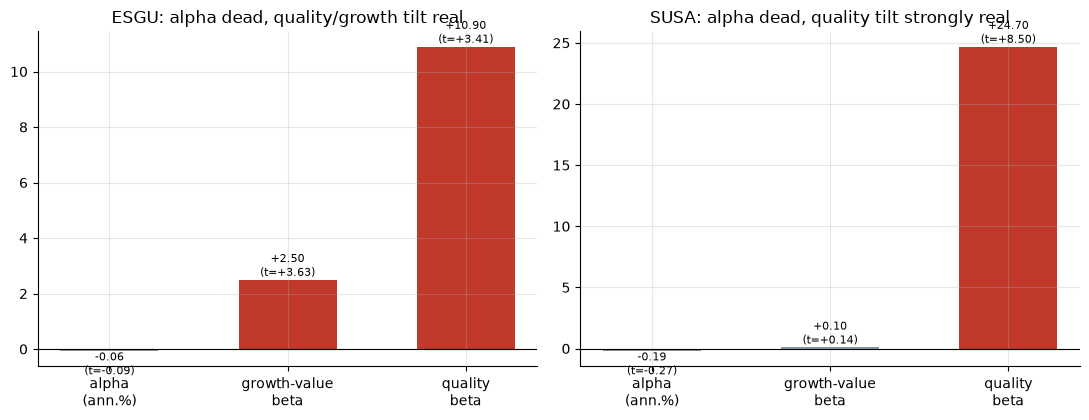

In [4]:
if HAVE_REAL:
    q_e = rets['QUAL'] - rets['SPY']; q_s = rets['QUAL'] - rets['IVV']
    fac_e = st.factor_decomposition(rets['ESGU'], rets['SPY'], gv_spread, q_e)
    fac_s = st.factor_decomposition(rets['SUSA'], rets['IVV'], gv_spread, q_s)
else:
    fac_e = fac_s = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
labs = ['alpha\n(ann.%)', 'growth-value\nbeta', 'quality\nbeta']
ve = [R['esgu_alpha_ann'], R['esgu_beta_gv']*100, R['esgu_beta_q']*100]
te_ = [R['esgu_alpha_t'], R['esgu_beta_gv_t'], R['esgu_beta_q_t']]
vs = [R['susa_alpha_ann'], R['susa_beta_gv']*100, R['susa_beta_q']*100]
ts_ = [R['susa_alpha_t'], R['susa_beta_gv_t'], R['susa_beta_q_t']]
a1.bar(labs, ve, color=[RED if abs(t)>=2 else GREY for t in te_], width=.55)
for i,(v,t_) in enumerate(zip(ve, te_)): a1.annotate(f'{v:+.2f}\n(t={t_:+.2f})',
    (i,v), ha='center', va='bottom' if v>=0 else 'top', fontsize=8)
a1.axhline(0,c='k',lw=.8); a1.set_title('ESGU: alpha dead, quality/growth tilt real')
a2.bar(labs, vs, color=[RED if abs(t)>=2 else GREY for t in ts_], width=.55)
for i,(v,t_) in enumerate(zip(vs, ts_)): a2.annotate(f'{v:+.2f}\n(t={t_:+.2f})',
    (i,v), ha='center', va='bottom' if v>=0 else 'top', fontsize=8)
a2.axhline(0,c='k',lw=.8); a2.set_title('SUSA: alpha dead, quality tilt strongly real')
plt.tight_layout(); plt.show()

> 💡 In plain words: for both funds the alpha (red only if \|t\|≥2) stays **grey** — -0.064%/yr at *t* = -0.09 (ESGU), -0.187%/yr at *t* = -0.27 (SUSA). The **quality beta is the one bar that's genuinely red**: *t* = 3.41 (ESGU), *t* = 8.50 (SUSA) — a real, measurable factor exposure. ESGU's growth-value beta is also real but tiny (*t* = 3.63); SUSA's is indistinguishable from zero (*t* = 0.14) because SUSA screens rather than tilts by sector weight. For SUSA specifically, the point estimate shrinks from -0.644%/yr (raw) to -0.187%/yr (factor-adjusted) — about 70% of the (statistically insignificant) raw gap is quality-factor beta, not stock-picking.

### 4d · Faithful-engine & power control — we know the truth here

Synthetic correlated-return world (fund vs benchmark, ρ = 0.97), TUNABLE planted daily premium. The null (premium = 0) is checked over **20 seeds** — never a single stream.

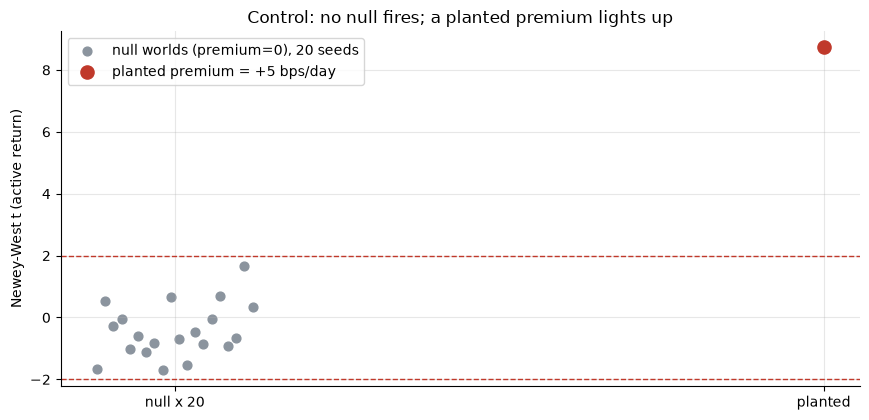

null: mean t = -0.43 (sd 0.88), |t|>=2 in 0/20 seeds  |  planted t = +8.73


In [5]:
null_ts = []
for s_ in range(20):
    w = data.synthetic_world(premium_bps=0.0, seed=664 + s_)
    null_ts.append(st.synthetic_detect(w)['t'])
null_ts = np.asarray(null_ts)
w = data.synthetic_world(premium_bps=5.0, seed=664)
planted_t = st.synthetic_detect(w)['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (premium=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted premium = +5 bps/day')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Newey-West t (active return)')
ax.set_title('Control: no null fires; a planted premium lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.43 (sd 0.88) and **never** crosses the bar; a planted +5 bps/day premium reads t = 8.73. The machinery is unbiased — the real-tape near-zero *t*'s are the genuine article, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — ESGU−SPY NW *t* = **-0.08** (-0.057%/yr, n=2,402); SUSA−IVV NW *t* = **-1.07** (-0.644%/yr, n=5,387). Neither clears \|t\| ≥ 2 in either direction — no premium, no penalty.
- **Tradability `MIRAGE`** — net of a documented 0.055–0.220%/yr expense-ratio gap plus one-way costs and a 30 bps/yr borrow drag, both spreads run further negative (-0.378%/yr, -0.953%/yr) while carrying 3.75–4.78%/yr of real, uncompensated tracking error.
- **"Growth/quality tilt?" `CONFIRMED`** — quality beta *t* = 3.41 / 8.50, ESGU growth-value beta *t* = 3.63. The tilt is real; the return edge it was supposed to explain never was.

## 6 · Going further

- **The academic record stays genuinely split** — Friede/Busch/Bassen (2015) lean mildly positive in the meta-literature; Bolton & Kacperczyk (2021) find a carbon *premium* implying ESG exclusion should mildly *underperform*; Pástor-Stambaugh-Taylor (2021) show realized alpha can be positive in a demand-driven transition even as expected alpha is negative in equilibrium. This study's null result is consistent with all three once you account for fees and the growth/quality tilt.
- **International and small-cap ESG products, and ESG-momentum (ratings upgrades/downgrades) strategies**, are natural sequels — this study only tests the two flagship US large-cap products at the fund level.
- **Dedup map:** [211-sin-stocks](../../211-sin-stocks/) (the mirror claim, individual tickers), [200-roe-quality](../../200-roe-quality/) (the quality factor on its own terms), [246-defensive-sectors](../../246-defensive-sectors/), [335-buzz-sentiment-etf](../../335-buzz-sentiment-etf/) and [334-ark-innovation](../../334-ark-innovation/) (thematic/active growth products, a different construction entirely) — full detail in [docs/references.md](../docs/references.md).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*